<a href="https://colab.research.google.com/github/rizwankuttu0-cyber/turbo-charger/blob/main/turbocharger_market_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Turbocharger Market Intelligence
### 2,000 listings | 326 anonymised sellers | 17 countries | 2025-2026
> Structured snapshot of the global turbocharger aftermarket. Pricing intelligence, seller dynamics,
> condition profiles and demand signals across industrial, marine and automotive segments.
> All seller identities anonymised. Source: public e-commerce platform listings.

---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 -- Setup & Load

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,"-m","pip","install","plotly","-q"])
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22",
    "axes.edgecolor":"#30363d","axes.labelcolor":"#e6edf3",
    "xtick.color":"#8b949e","ytick.color":"#8b949e",
    "text.color":"#e6edf3","grid.color":"#21262d",
    "grid.linestyle":"--","grid.alpha":0.5,
    "font.family":"monospace","axes.titlesize":12,"axes.titleweight":"bold",
})
PAL = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657","#79c0ff","#56d364","#e3b341"]
TIER_COLORS = {
    "Budget (<$500)":"#3fb950","Economy ($500-2K)":"#56d364",
    "Mid-Range ($2K-5K)":"#58a6ff","Premium ($5K-10K)":"#d2a8ff",
    "High-End ($10K-20K)":"#ffa657","Ultra ($20K+)":"#f78166",
}
COND_COLORS = {
    "New":"#3fb950","Remanufactured / Refurbished":"#58a6ff",
    "Used":"#ffa657","Parts Only":"#8b949e",
}
STIER_ORDER  = ["Power Seller (100+)","High Volume (50-99)","Active (20-49)","Regular (5-19)","Small (1-4)"]
STIER_COLORS = ["#f78166","#ffa657","#d2a8ff","#58a6ff","#3fb950"]

# INSERT DATASET PATH HERE
PATH = "/content/drive/MyDrive/Colab Notebooks/turbocharger_intelligence_v1.csv"
df   = pd.read_csv(PATH, low_memory=False)

print(f"Loaded      : {len(df):,} rows x {df.shape[1]} columns")
print(f"Brands      : {df['brand_clean'].nunique():,} unique")
print(f"Sellers     : {df['seller_id'].nunique():,} anonymised")
print(f"Countries   : {df['seller_country'].nunique():,}")
print(f"Price range : ${df['price'].min():,.0f} to ${df['price'].max():,.0f}")
print(f"Mean price  : ${df['price'].mean():,.2f}")
print(f"Median price: ${df['price'].median():,.2f}")
print()
for k,v in df["condition_group"].value_counts().items():
    print(f"  {k:<35}: {v:,}  ({100*v/len(df):.1f}%)")


Loaded      : 2,000 rows x 34 columns
Brands      : 145 unique
Sellers     : 326 anonymised
Countries   : 17
Price range : $1 to $45,000
Mean price  : $7,365.74
Median price: $6,315.33

  New                                : 1,716  (85.8%)
  Remanufactured / Refurbished       : 163  (8.2%)
  Used                               : 120  (6.0%)
  Parts Only                         : 1  (0.1%)


---
## Cell 2 -- Price Intelligence
> **85.8% of listings are Premium, High-End or Ultra** (above $5K). Used listings average $10,036 -- above New ($7,254) -- because used stock skews toward high-specification OEM heavy equipment units.


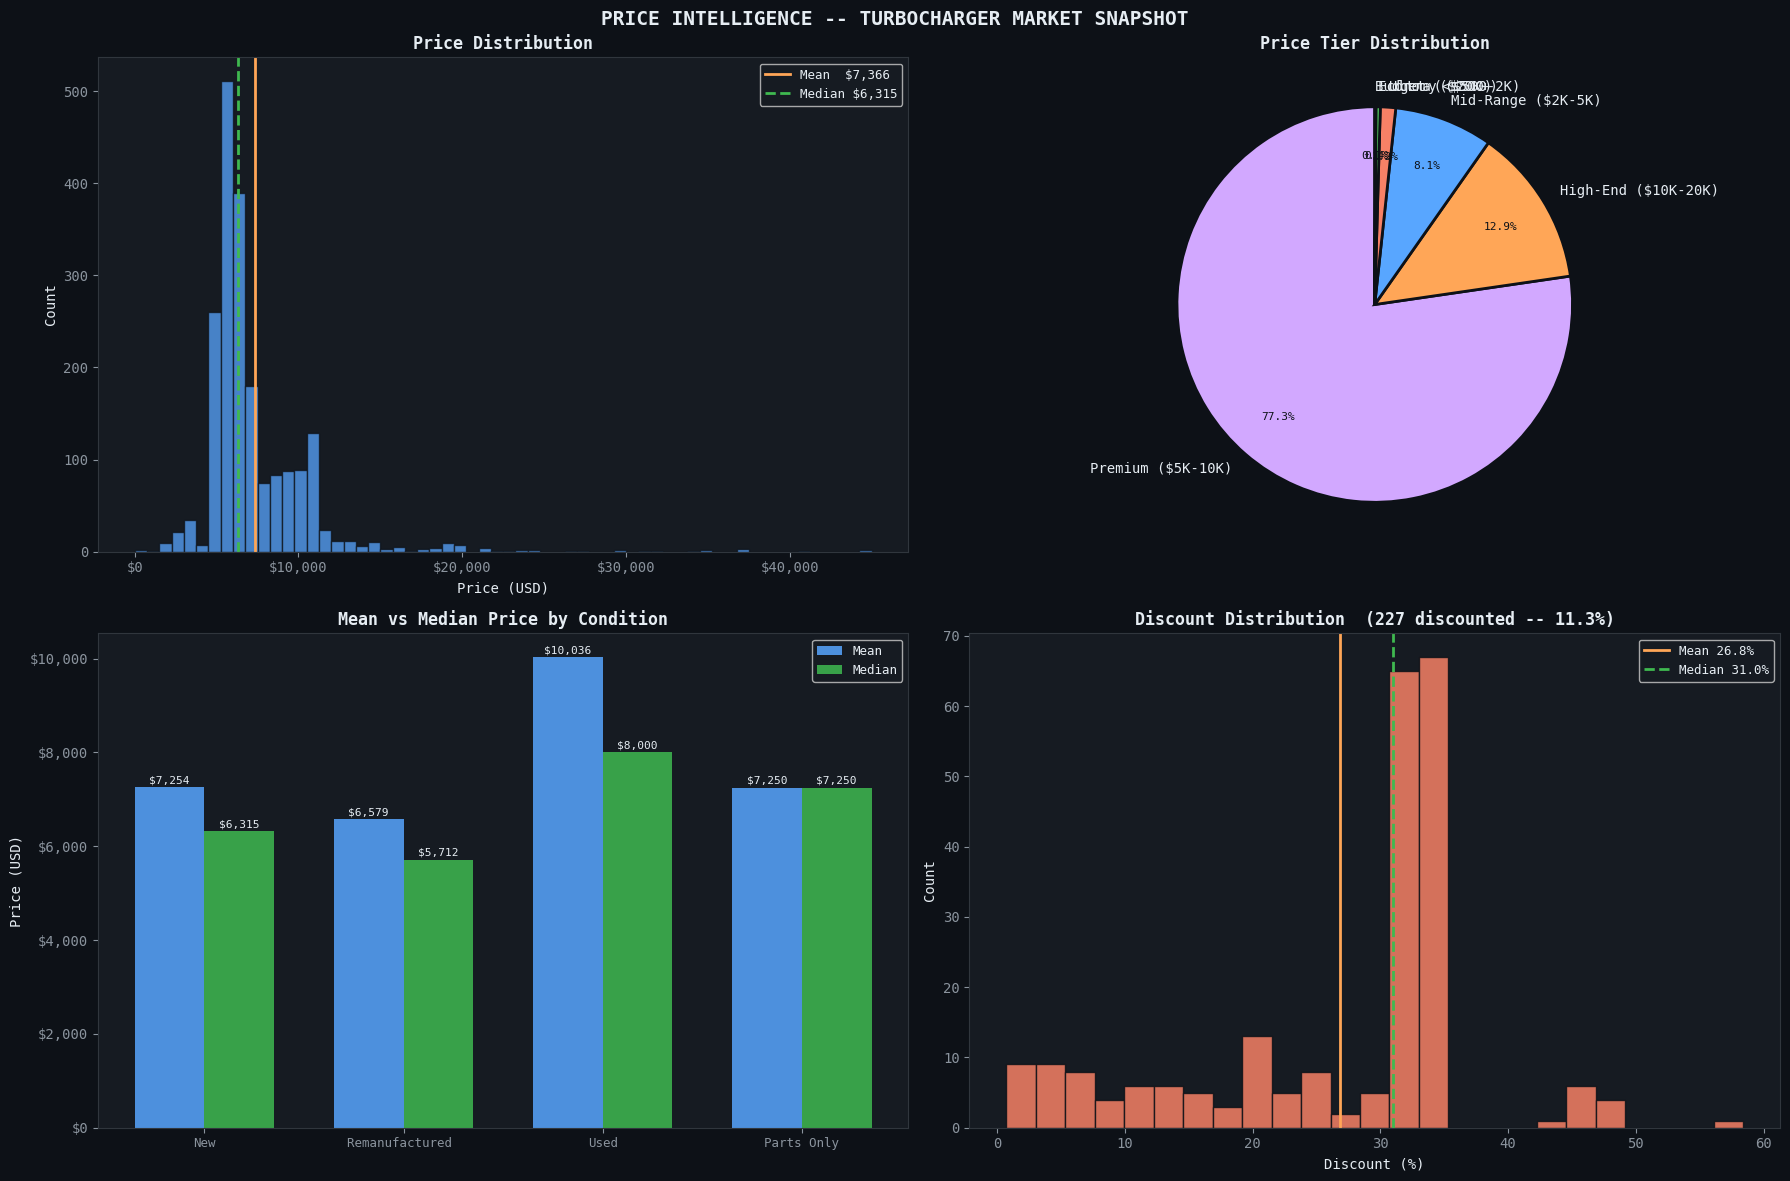

Used avg price        : $10,035.83
New avg price         : $7,253.78
Used premium over New : 38.4%
Max discount pct      : 58.4%
Avg discount pct      : 26.8%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18,12))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("PRICE INTELLIGENCE -- TURBOCHARGER MARKET SNAPSHOT",
             fontsize=14, fontweight="bold", color="#e6edf3")

ax = axes[0,0]
ax.hist(df["price"], bins=60, color="#58a6ff", alpha=0.75, edgecolor="#0d1117")
ax.axvline(df["price"].mean(),   color="#ffa657", lw=2, label=f"Mean  ${df['price'].mean():,.0f}")
ax.axvline(df["price"].median(), color="#3fb950", lw=2, ls="--", label=f"Median ${df['price'].median():,.0f}")
ax.set_title("Price Distribution")
ax.set_xlabel("Price (USD)"); ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.legend(fontsize=9)

ax = axes[0,1]
tier_vc = df["price_tier"].value_counts()
colors_t = [TIER_COLORS.get(t,"#8b949e") for t in tier_vc.index]
wedges,texts,autotexts = ax.pie(tier_vc.values, labels=tier_vc.index,
    colors=colors_t, autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor="#0d1117",linewidth=2))
for at in autotexts: at.set_fontsize(8); at.set_color("#0d1117")
ax.set_title("Price Tier Distribution")

ax = axes[1,0]
cond_stats = df.groupby("condition_group")["price"].agg(["mean","median"]).reindex(
    ["New","Remanufactured / Refurbished","Used","Parts Only"]).dropna()
x = np.arange(len(cond_stats)); w = 0.35
b1 = ax.bar(x-w/2, cond_stats["mean"],   w, color="#58a6ff", alpha=0.85, label="Mean")
b2 = ax.bar(x+w/2, cond_stats["median"], w, color="#3fb950", alpha=0.85, label="Median")
for bar,val in zip(b1, cond_stats["mean"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+80, f"${val:,.0f}",
            ha="center", fontsize=8, color="#e6edf3")
for bar,val in zip(b2, cond_stats["median"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+80, f"${val:,.0f}",
            ha="center", fontsize=8, color="#e6edf3")
ax.set_xticks(x); ax.set_xticklabels([c[:15] for c in cond_stats.index], fontsize=9)
ax.set_title("Mean vs Median Price by Condition")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.legend(fontsize=9)

ax = axes[1,1]
disc = df[df["has_discount"]==1]["discount_pct"].dropna()
ax.hist(disc, bins=25, color="#f78166", alpha=0.85, edgecolor="#0d1117")
ax.axvline(disc.mean(),   color="#ffa657", lw=2, label=f"Mean {disc.mean():.1f}%")
ax.axvline(disc.median(), color="#3fb950", lw=2, ls="--", label=f"Median {disc.median():.1f}%")
ax.set_title(f"Discount Distribution  ({len(disc):,} discounted -- {100*len(disc)/len(df):.1f}%)")
ax.set_xlabel("Discount (%)"); ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("price_intelligence.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

used_mean = df[df["condition_group"]=="Used"]["price"].mean()
new_mean  = df[df["condition_group"]=="New"]["price"].mean()
print(f"Used avg price        : ${used_mean:,.2f}")
print(f"New avg price         : ${new_mean:,.2f}")
print(f"Used premium over New : {((used_mean/new_mean)-1)*100:.1f}%")
print(f"Max discount pct      : {df['discount_pct'].max():.1f}%")
print(f"Avg discount pct      : {df['discount_pct'].mean():.1f}%")


---
## Cell 3 -- Brand Intelligence
> **Precision leads volume** with 312 listings. **Ferrari commands the highest average price** at $14,782. Cummins and Holset dominate the industrial diesel segment. 15.2% of all listings are industrial or marine application.


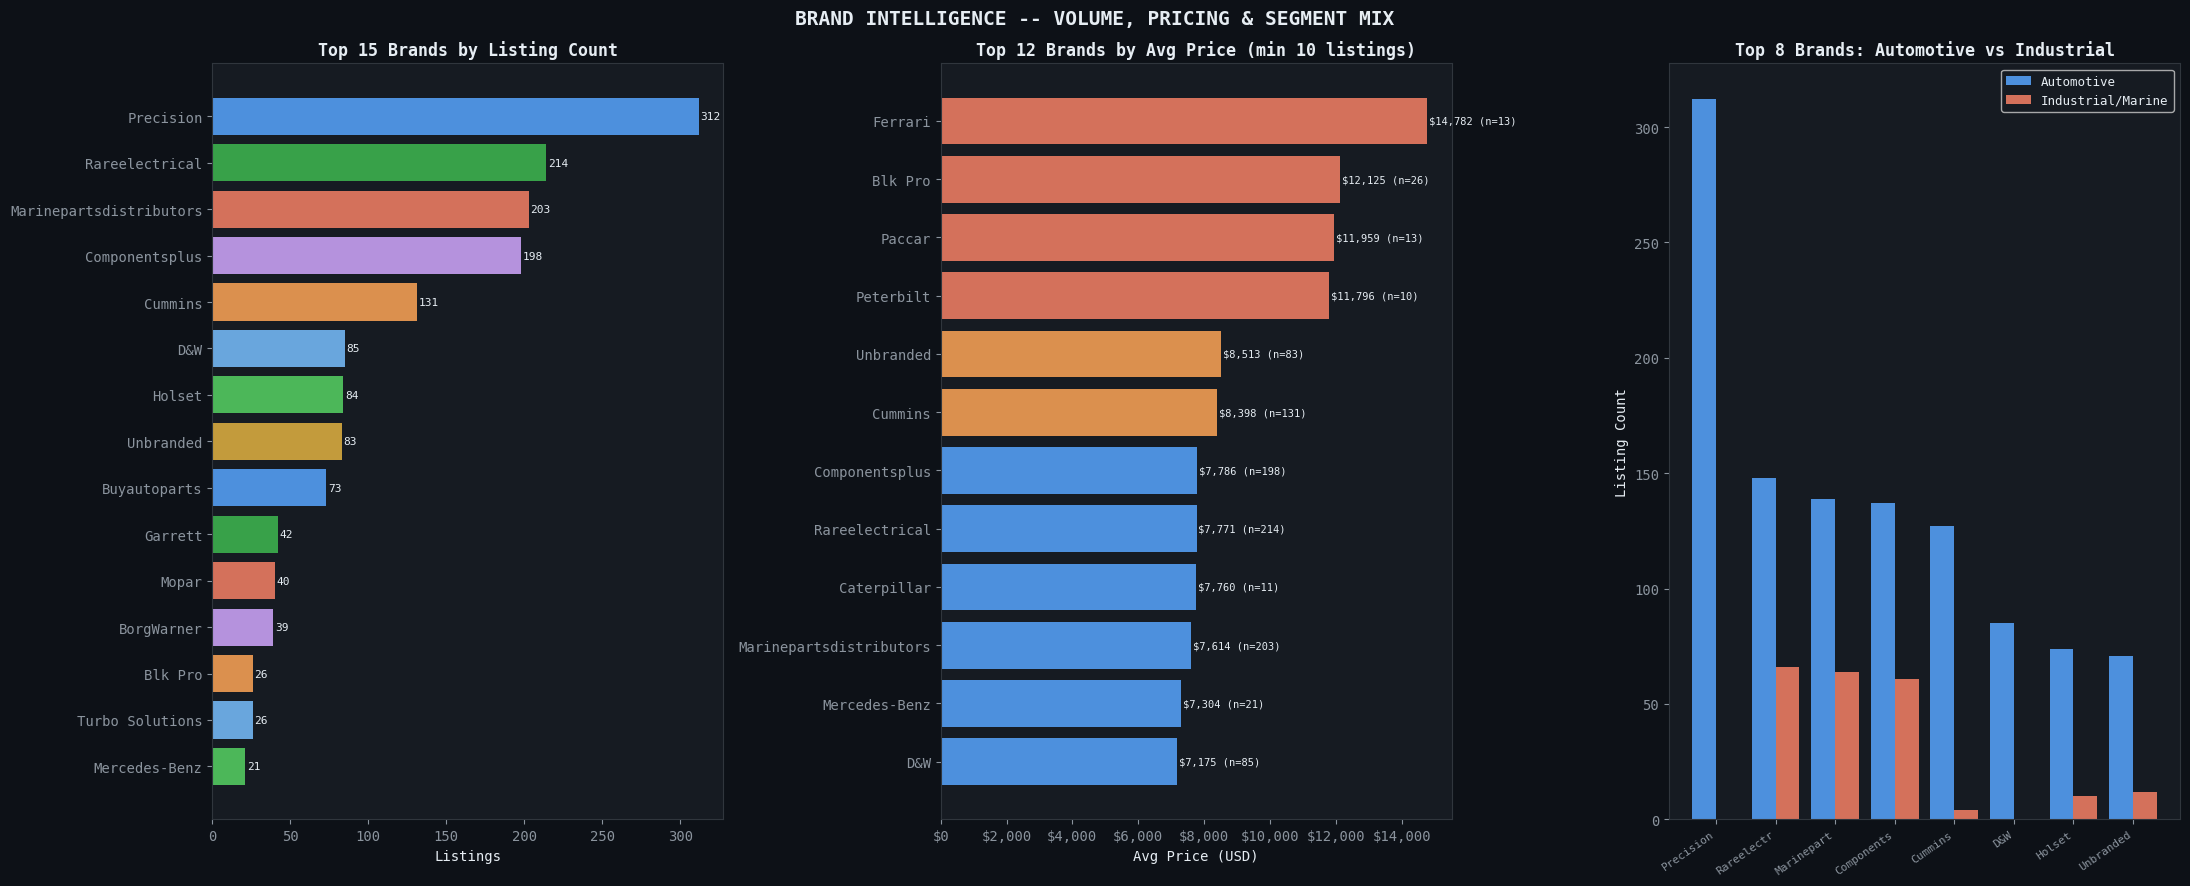

Industrial/marine listings: 303 (15.2%)
Ferrari avg price         : $14,781.55
Precision avg price       : $6,107.82


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22,9))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("BRAND INTELLIGENCE -- VOLUME, PRICING & SEGMENT MIX",
             fontsize=14, fontweight="bold", color="#e6edf3")

ax = axes[0]
top15 = df["brand_clean"].value_counts().head(15)
bars = ax.barh(top15.index, top15.values,
               color=[PAL[i%len(PAL)] for i in range(len(top15))], alpha=0.85)
for bar,val in zip(bars, top15.values):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f"{val:,}",
            va="center", fontsize=8, color="#e6edf3")
ax.set_title("Top 15 Brands by Listing Count")
ax.set_xlabel("Listings"); ax.invert_yaxis()

ax = axes[1]
brand_price = (df.groupby("brand_clean").agg(count=("price","count"), avg_price=("price","mean"))
               .query("count >= 10").sort_values("avg_price", ascending=False).head(12))
colors_bp = ["#f78166" if v>10000 else "#ffa657" if v>8000 else "#58a6ff"
             for v in brand_price["avg_price"]]
bars2 = ax.barh(brand_price.index, brand_price["avg_price"], color=colors_bp, alpha=0.85)
for bar,val,cnt in zip(bars2, brand_price["avg_price"], brand_price["count"]):
    ax.text(val+50, bar.get_y()+bar.get_height()/2,
            f"${val:,.0f} (n={cnt})", va="center", fontsize=7.5, color="#e6edf3")
ax.set_title("Top 12 Brands by Avg Price (min 10 listings)")
ax.set_xlabel("Avg Price (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.invert_yaxis()

ax = axes[2]
top8 = df["brand_clean"].value_counts().head(8).index
ind_data = (df[df["brand_clean"].isin(top8)].groupby(["brand_clean","is_industrial"])
            .size().unstack(fill_value=0))
ind_data.columns = ["Automotive","Industrial/Marine"]
ind_data = ind_data.reindex(top8)
x3 = np.arange(len(ind_data)); w3 = 0.4
ax.bar(x3-w3/2, ind_data["Automotive"],        w3, color="#58a6ff", alpha=0.85, label="Automotive")
ax.bar(x3+w3/2, ind_data["Industrial/Marine"],  w3, color="#f78166", alpha=0.85, label="Industrial/Marine")
ax.set_xticks(x3)
ax.set_xticklabels([b[:10] for b in ind_data.index], rotation=35, ha="right", fontsize=8)
ax.set_title("Top 8 Brands: Automotive vs Industrial")
ax.set_ylabel("Listing Count"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("brand_intelligence.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Industrial/marine listings: {df['is_industrial'].sum():,} ({100*df['is_industrial'].mean():.1f}%)")
print(f"Ferrari avg price         : ${df[df['brand_clean']=='Ferrari']['price'].mean():,.2f}")
print(f"Precision avg price       : ${df[df['brand_clean']=='Precision']['price'].mean():,.2f}")


---
## Cell 4 -- Seller & Market Dynamics
> **Power Sellers account for 58.5% of all inventory** but Small sellers price 7% higher -- they list rarer, more specialised units. Local Pickup listings carry a $4,955 premium over worldwide shipping.


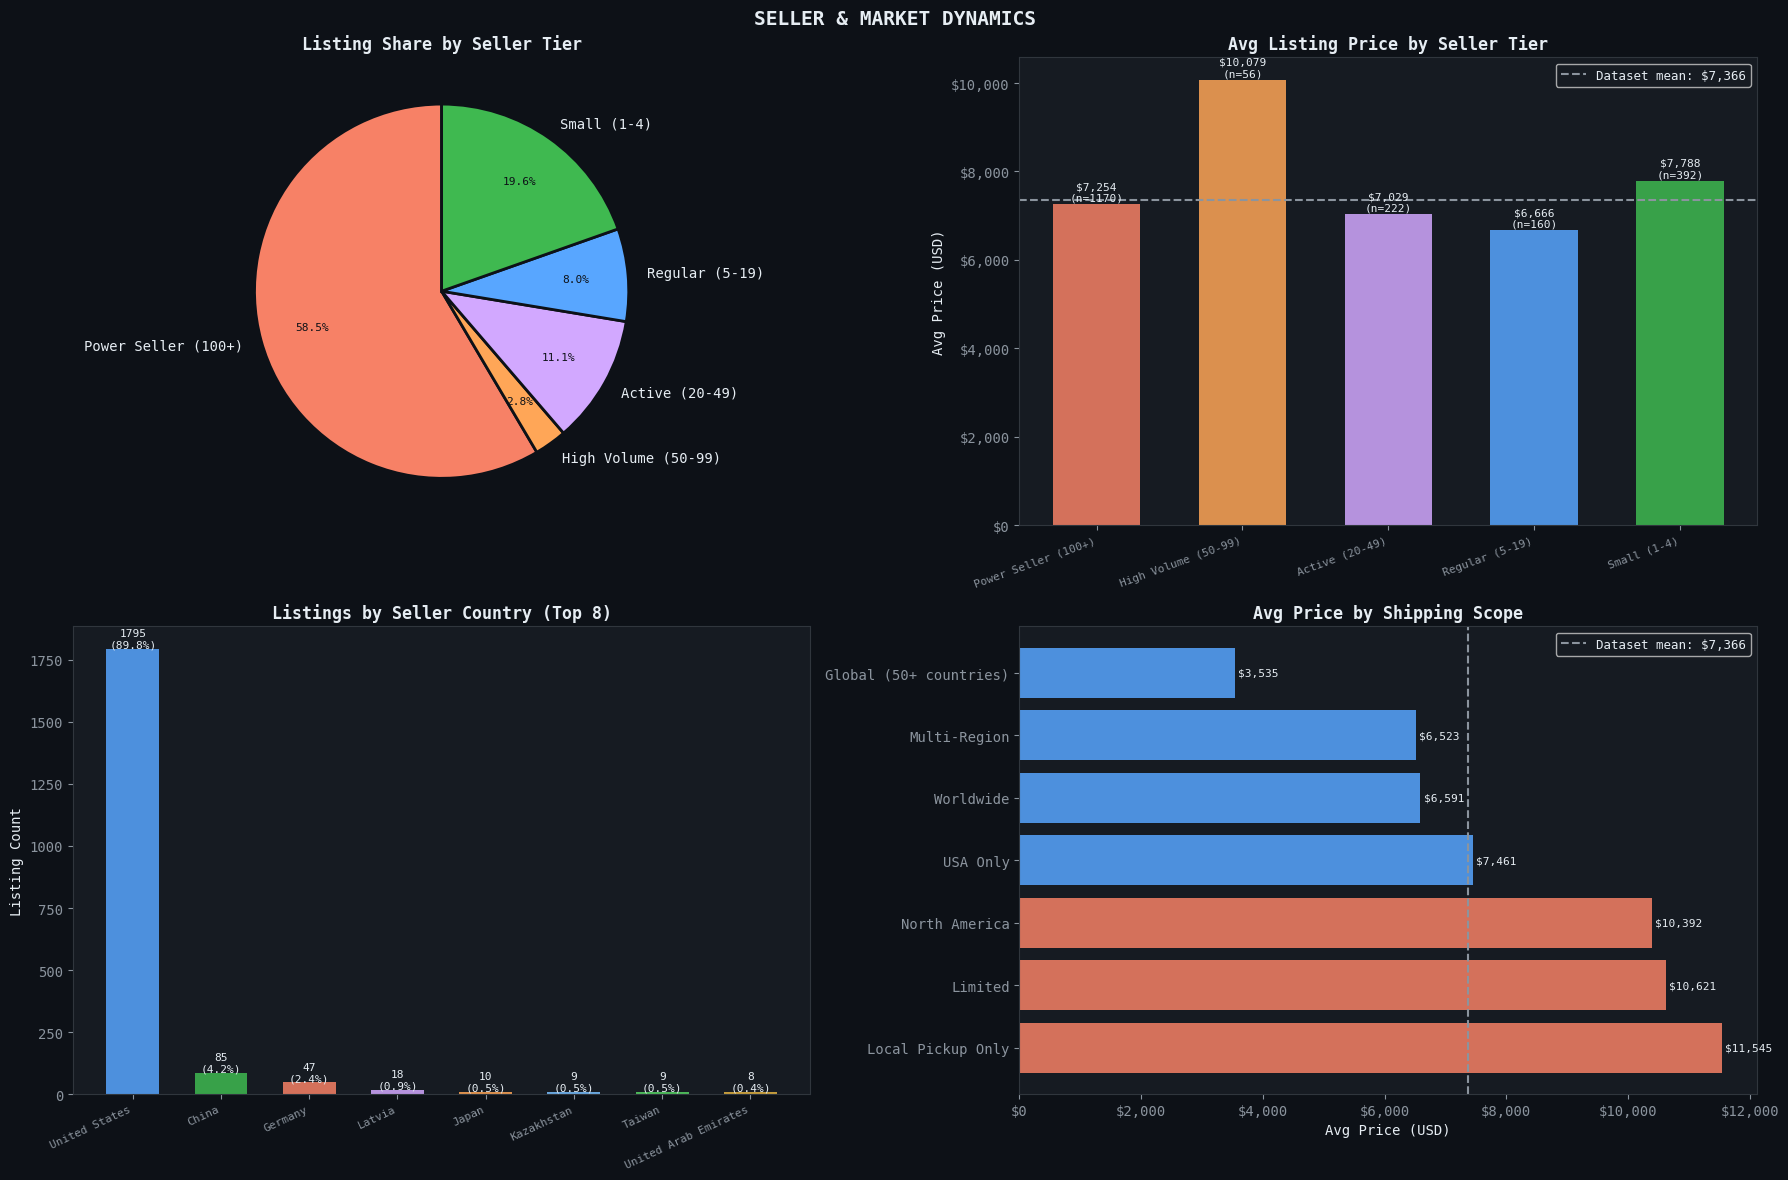

Power Seller avg : $7,254.20
Small seller avg : $7,787.59
Small vs Power   : 7.4%
Local Pickup avg : $11,545.22
Worldwide avg    : $6,590.68
Pickup premium   : $4,954.55


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18,12))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("SELLER & MARKET DYNAMICS",
             fontsize=14, fontweight="bold", color="#e6edf3")

ax = axes[0,0]
st_vc = df["seller_tier"].value_counts().reindex(STIER_ORDER).dropna()
wedges,texts,autotexts = ax.pie(st_vc.values, labels=st_vc.index,
    colors=STIER_COLORS[:len(st_vc)], autopct="%1.1f%%", startangle=90, pctdistance=0.72,
    wedgeprops=dict(edgecolor="#0d1117",linewidth=2))
for at in autotexts: at.set_fontsize(8); at.set_color("#0d1117")
ax.set_title("Listing Share by Seller Tier")

ax = axes[0,1]
tier_price = df.groupby("seller_tier")["price"].agg(["mean","count"]).reindex(STIER_ORDER).dropna()
bars3 = ax.bar(tier_price.index, tier_price["mean"],
               color=STIER_COLORS[:len(tier_price)], alpha=0.85, width=0.6)
ax.axhline(df["price"].mean(), color="#8b949e", ls="--", lw=1.5,
           label=f"Dataset mean: ${df['price'].mean():,.0f}")
for bar,val,cnt in zip(bars3, tier_price["mean"], tier_price["count"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+80,
            f"${val:,.0f}\n(n={cnt})", ha="center", fontsize=8, color="#e6edf3")
ax.set_title("Avg Listing Price by Seller Tier")
ax.set_ylabel("Avg Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
ax.legend(fontsize=9)

ax = axes[1,0]
ctry_vc = df["seller_country"].value_counts().head(8)
bars4 = ax.bar(ctry_vc.index, ctry_vc.values,
               color=[PAL[i%len(PAL)] for i in range(len(ctry_vc))], alpha=0.85, width=0.6)
for bar,val in zip(bars4, ctry_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+5,
            f"{val}\n({100*val/len(df):.1f}%)", ha="center", fontsize=8, color="#e6edf3")
ax.set_title("Listings by Seller Country (Top 8)")
ax.set_ylabel("Listing Count")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

ax = axes[1,1]
scope_price = df.groupby("shipping_scope")["price"].mean().sort_values(ascending=False)
scope_price = scope_price[scope_price.index != "Unknown"]
colors_sc = ["#f78166" if v>10000 else "#ffa657" if v>8000 else "#58a6ff"
             for v in scope_price.values]
bars5 = ax.barh(scope_price.index, scope_price.values, color=colors_sc, alpha=0.85)
ax.axvline(df["price"].mean(), color="#8b949e", ls="--", lw=1.5,
           label=f"Dataset mean: ${df['price'].mean():,.0f}")
for bar,val in zip(bars5, scope_price.values):
    ax.text(val+50, bar.get_y()+bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=8, color="#e6edf3")
ax.set_title("Avg Price by Shipping Scope")
ax.set_xlabel("Avg Price (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("seller_dynamics.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
ps_avg = df[df["seller_tier"]=="Power Seller (100+)"]["price"].mean()
sm_avg = df[df["seller_tier"]=="Small (1-4)"]["price"].mean()
lp_avg = df[df["shipping_scope"]=="Local Pickup Only"]["price"].mean()
ww_avg = df[df["shipping_scope"]=="Worldwide"]["price"].mean()
print(f"Power Seller avg : ${ps_avg:,.2f}")
print(f"Small seller avg : ${sm_avg:,.2f}")
print(f"Small vs Power   : {((sm_avg/ps_avg)-1)*100:.1f}%")
print(f"Local Pickup avg : ${lp_avg:,.2f}")
print(f"Worldwide avg    : ${ww_avg:,.2f}")
print(f"Pickup premium   : ${lp_avg-ww_avg:,.2f}")


---
## Cell 5 -- Pricing Signals: Deals, Premiums & Relative Value
> **196 listings are underpriced** (>20% below condition median). **376 are overpriced** (>50% above). Listings with formal part numbers price $1,247 higher on average.


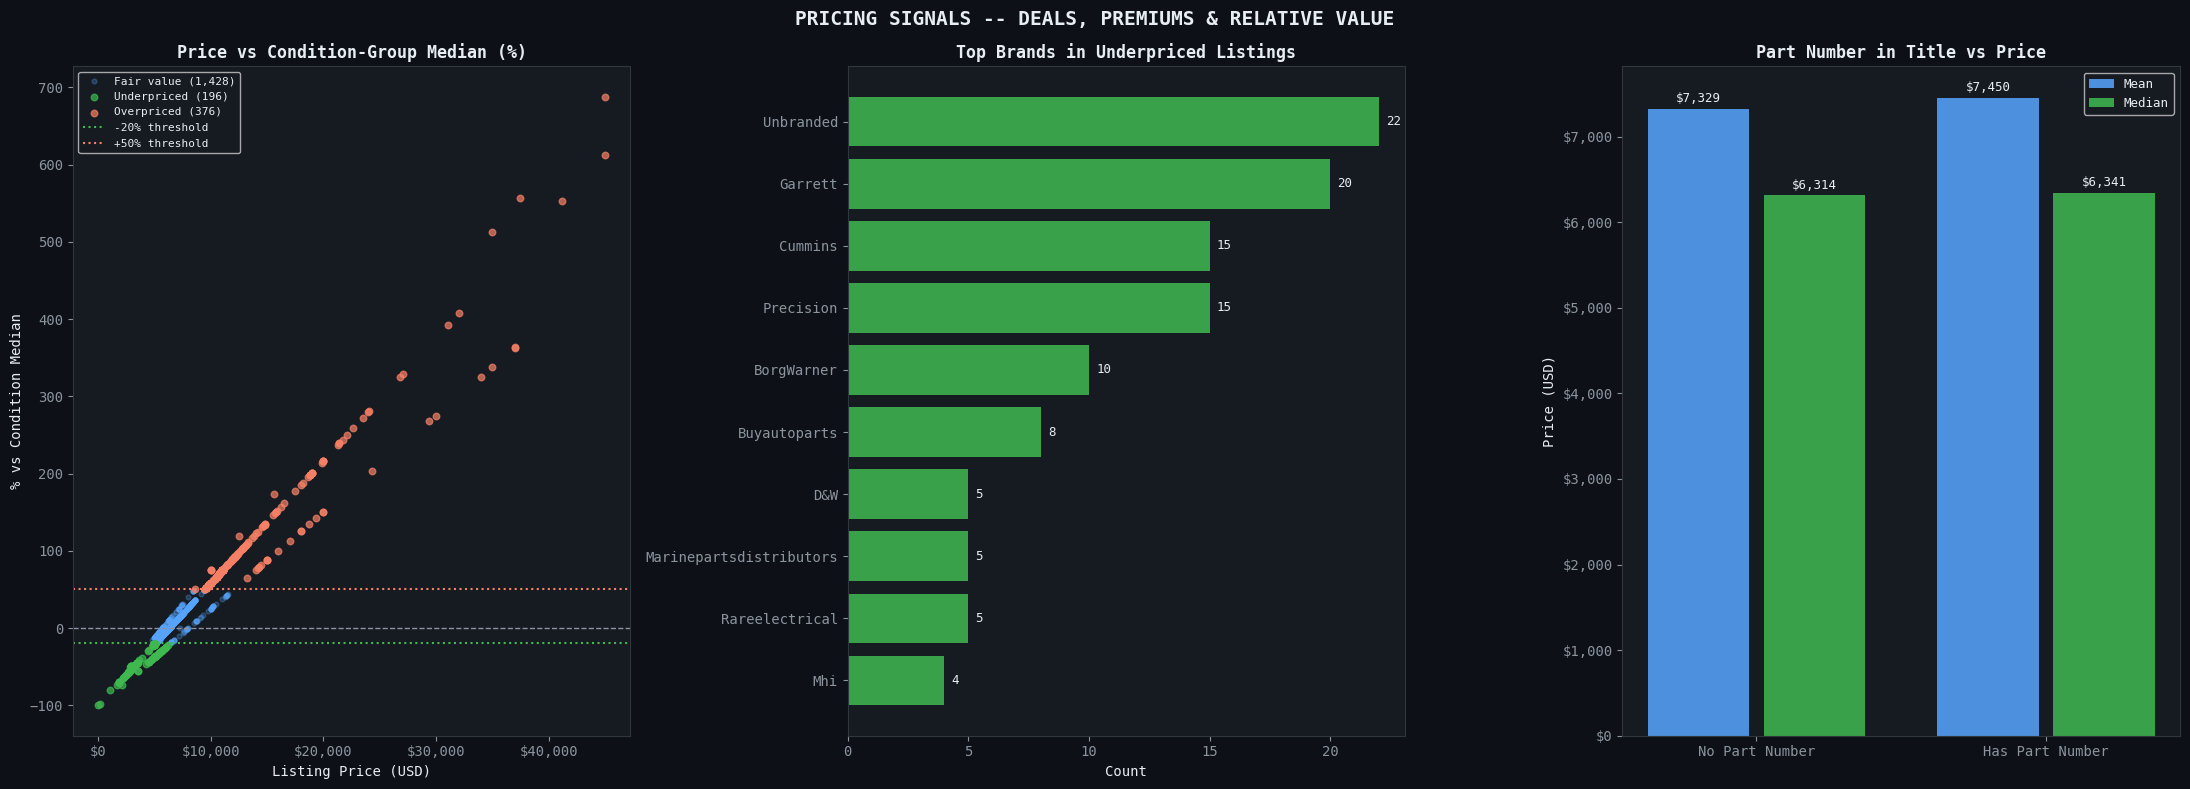

With part number avg   : $7,449.90
Without part number avg: $7,329.15
Part number premium    : $120.75
Underpriced listings   : 196
Overpriced listings    : 376


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22,8))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("PRICING SIGNALS -- DEALS, PREMIUMS & RELATIVE VALUE",
             fontsize=14, fontweight="bold", color="#e6edf3")

ax = axes[0]
under = df[df["is_underpriced"]==1]
over  = df[df["is_overpriced"]==1]
norm  = df[(df["is_underpriced"]==0) & (df["is_overpriced"]==0)]
ax.scatter(norm["price"],  norm["price_vs_condition_median"],
           alpha=0.25, s=12, color="#58a6ff", label=f"Fair value ({len(norm):,})")
ax.scatter(under["price"], under["price_vs_condition_median"],
           alpha=0.7, s=22, color="#3fb950", label=f"Underpriced ({len(under):,})")
ax.scatter(over["price"],  over["price_vs_condition_median"],
           alpha=0.7, s=22, color="#f78166", label=f"Overpriced ({len(over):,})")
ax.axhline(0,   color="#8b949e", ls="--", lw=1)
ax.axhline(-20, color="#3fb950", ls=":", lw=1.5, label="-20% threshold")
ax.axhline(50,  color="#f78166", ls=":", lw=1.5, label="+50% threshold")
ax.set_title("Price vs Condition-Group Median (%)")
ax.set_xlabel("Listing Price (USD)"); ax.set_ylabel("% vs Condition Median")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.legend(fontsize=8)

ax = axes[1]
ub = df[df["is_underpriced"]==1]["brand_clean"].value_counts().head(10)
bars6 = ax.barh(ub.index, ub.values, color="#3fb950", alpha=0.85)
for bar,val in zip(bars6, ub.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f"{val}", va="center", fontsize=9, color="#e6edf3")
ax.set_title("Top Brands in Underpriced Listings")
ax.set_xlabel("Count"); ax.invert_yaxis()

ax = axes[2]
pn_stats = df.groupby("has_part_number")["price"].agg(["mean","median","count"])
ax.bar([0,1],     pn_stats["mean"],   0.35, color="#58a6ff", alpha=0.85, label="Mean")
ax.bar([0.4,1.4], pn_stats["median"], 0.35, color="#3fb950", alpha=0.85, label="Median")
for i,row in enumerate(pn_stats.itertuples()):
    ax.text(i,     row.mean+80,   f"${row.mean:,.0f}",   ha="center", fontsize=9, color="#e6edf3")
    ax.text(i+0.4, row.median+80, f"${row.median:,.0f}", ha="center", fontsize=9, color="#e6edf3")
ax.set_xticks([0.2,1.2]); ax.set_xticklabels(["No Part Number","Has Part Number"])
ax.set_title("Part Number in Title vs Price")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("pricing_signals.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
pn_yes = df[df["has_part_number"]==1]["price"].mean()
pn_no  = df[df["has_part_number"]==0]["price"].mean()
print(f"With part number avg   : ${pn_yes:,.2f}")
print(f"Without part number avg: ${pn_no:,.2f}")
print(f"Part number premium    : ${pn_yes-pn_no:,.2f}")
print(f"Underpriced listings   : {df['is_underpriced'].sum():,}")
print(f"Overpriced listings    : {df['is_overpriced'].sum():,}")


---
## Cell 6 -- Geographic Intelligence
> **89.8% of supply originates in the US**. International sellers price higher on average. Local Pickup commands a $4,955 premium -- reflecting large industrial units that cannot be shipped economically.


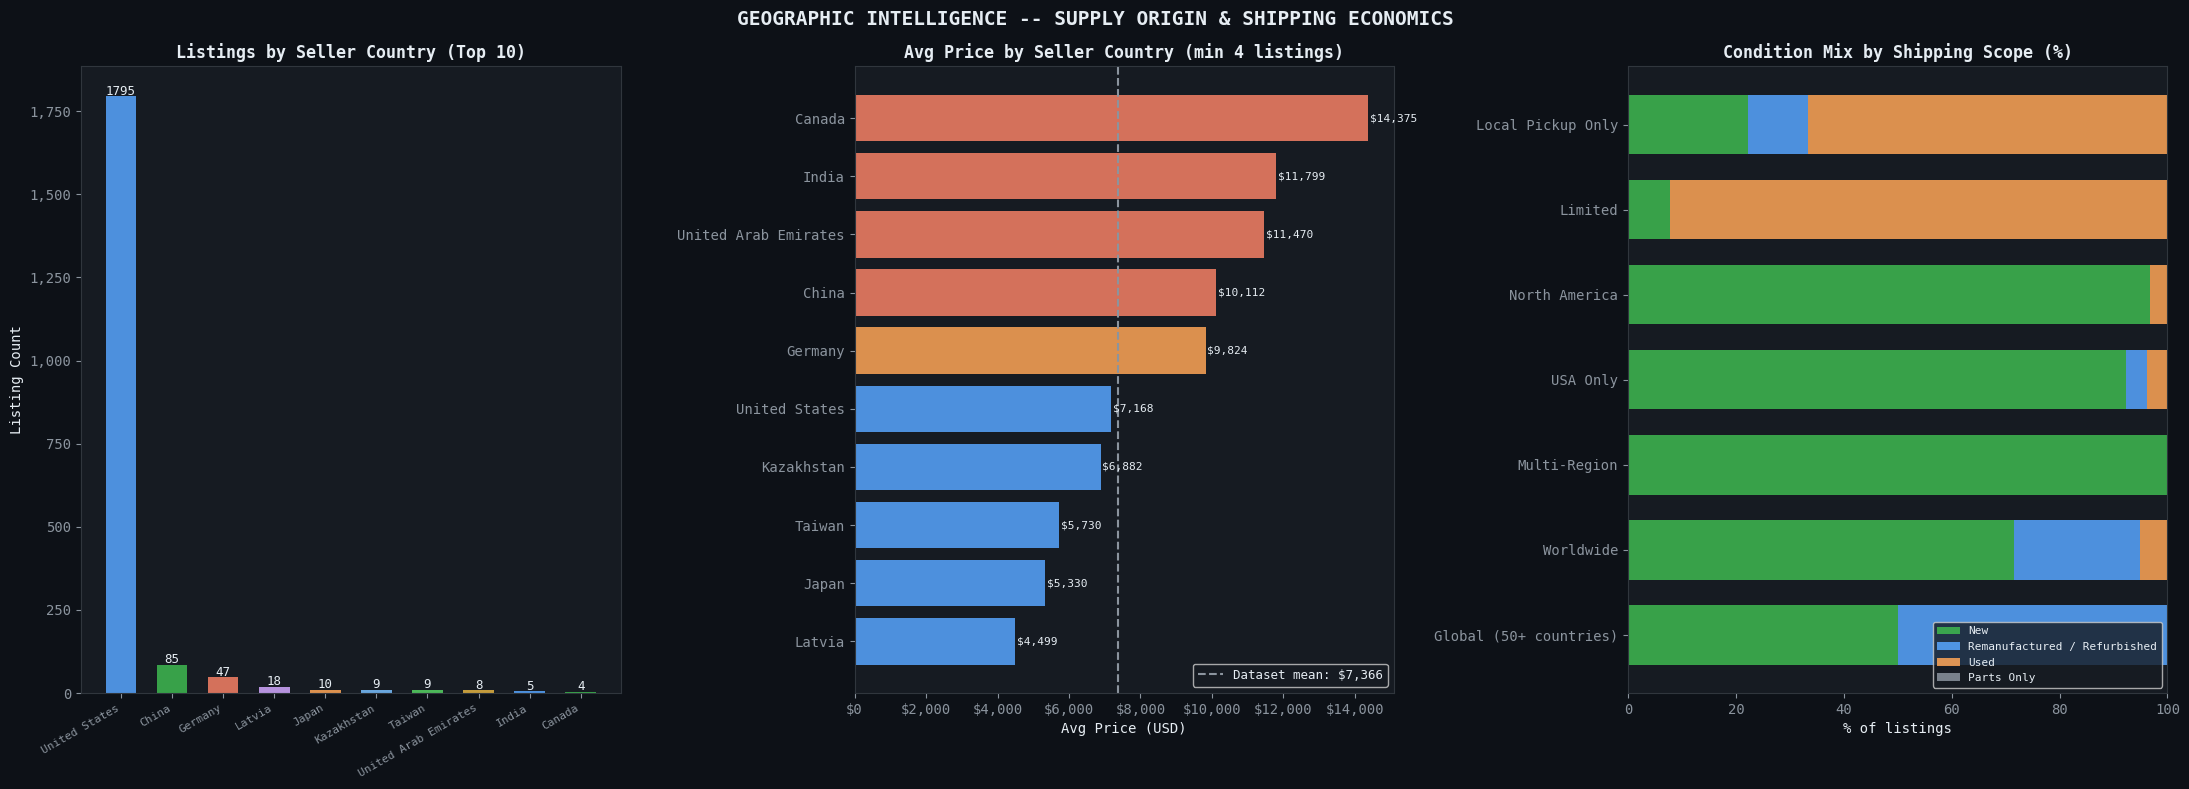

US seller avg           : $7,168.47
International seller avg: $9,093.03
International premium   : $1,924.55
Local Pickup vs Worldwide: $4,954.55 premium


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22,8))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("GEOGRAPHIC INTELLIGENCE -- SUPPLY ORIGIN & SHIPPING ECONOMICS",
             fontsize=14, fontweight="bold", color="#e6edf3")

ax = axes[0]
ctry_vc2 = df["seller_country"].value_counts().head(10)
bars7 = ax.bar(ctry_vc2.index, ctry_vc2.values,
               color=[PAL[i%len(PAL)] for i in range(len(ctry_vc2))], alpha=0.85, width=0.6)
for bar,val in zip(bars7, ctry_vc2.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+5, f"{val}",
            ha="center", fontsize=9, color="#e6edf3")
ax.set_title("Listings by Seller Country (Top 10)")
ax.set_ylabel("Listing Count")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

ax = axes[1]
ctry_price = (df.groupby("seller_country").agg(count=("price","count"), mean_price=("price","mean"))
              .query("count >= 4").sort_values("mean_price", ascending=False).head(10))
colors_cp = ["#f78166" if v>10000 else "#ffa657" if v>8000 else "#58a6ff"
             for v in ctry_price["mean_price"]]
bars8 = ax.barh(ctry_price.index, ctry_price["mean_price"], color=colors_cp, alpha=0.85)
ax.axvline(df["price"].mean(), color="#8b949e", ls="--", lw=1.5,
           label=f"Dataset mean: ${df['price'].mean():,.0f}")
for bar,val in zip(bars8, ctry_price["mean_price"]):
    ax.text(val+50, bar.get_y()+bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=8, color="#e6edf3")
ax.set_title("Avg Price by Seller Country (min 4 listings)")
ax.set_xlabel("Avg Price (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${int(x):,}"))
ax.invert_yaxis(); ax.legend(fontsize=9)

ax = axes[2]
scope_cond = pd.crosstab(df["shipping_scope"], df["condition_group"], normalize="index") * 100
scope_cond = scope_cond.drop("Unknown", errors="ignore")
scope_order = ["Local Pickup Only","Limited","North America","USA Only",
               "Multi-Region","Worldwide","Global (50+ countries)"]
scope_cond = scope_cond.reindex([s for s in scope_order if s in scope_cond.index])
bottom = np.zeros(len(scope_cond))
cond_cols = {"New":"#3fb950","Remanufactured / Refurbished":"#58a6ff",
             "Used":"#ffa657","Parts Only":"#8b949e"}
for cond, col in cond_cols.items():
    if cond in scope_cond.columns:
        ax.barh(scope_cond.index, scope_cond[cond].values, left=bottom,
                color=col, alpha=0.85, label=cond, height=0.7)
        bottom += scope_cond[cond].fillna(0).values
ax.set_title("Condition Mix by Shipping Scope (%)")
ax.set_xlabel("% of listings"); ax.invert_yaxis()
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("geographic_intelligence.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
int_avg = df[df["seller_country"]!="United States"]["price"].mean()
us_avg  = df[df["seller_country"]=="United States"]["price"].mean()
lp_avg  = df[df["shipping_scope"]=="Local Pickup Only"]["price"].mean()
ww_avg  = df[df["shipping_scope"]=="Worldwide"]["price"].mean()
print(f"US seller avg           : ${us_avg:,.2f}")
print(f"International seller avg: ${int_avg:,.2f}")
print(f"International premium   : ${int_avg-us_avg:,.2f}")
print(f"Local Pickup vs Worldwide: ${lp_avg-ww_avg:,.2f} premium")


---
## Cell 7 -- Full Market Intelligence Dashboard (Interactive)
> Nine-panel interactive dashboard. Hover over any element for exact values.


In [ ]:
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        "Price Distribution","Price Tier Split","Condition Mix",
        "Top 10 Brands by Volume","Seller Tier Share","Avg Price by Shipping",
        "Seller Country Supply","Discount Distribution","Pricing Signal Flags",
    ],
    specs=[
        [{"type":"xy"},    {"type":"domain"}, {"type":"domain"}],
        [{"type":"xy"},    {"type":"domain"}, {"type":"xy"}],
        [{"type":"xy"},    {"type":"xy"},     {"type":"xy"}],
    ],
    vertical_spacing=0.11, horizontal_spacing=0.07,
)

price_hist = df["price"].value_counts(bins=40).sort_index()
ph_x = [float(str(i).split(",")[0].replace("(","")) for i in price_hist.index]
fig.add_trace(go.Bar(x=ph_x, y=price_hist.values, marker_color="#58a6ff",
    showlegend=False, hovertemplate="~$%{x:,.0f}<br>%{y} listings<extra></extra>"),
    row=1, col=1)

tier_vc2 = df["price_tier"].value_counts()
fig.add_trace(go.Pie(labels=tier_vc2.index, values=tier_vc2.values,
    marker_colors=[TIER_COLORS.get(t,"#8b949e") for t in tier_vc2.index],
    hole=0.5, showlegend=False,
    hovertemplate="<b>%{label}</b><br>%{value:,} (%{percent})<extra></extra>"),
    row=1, col=2)

cond_vc = df["condition_group"].value_counts()
fig.add_trace(go.Pie(labels=cond_vc.index, values=cond_vc.values,
    marker_colors=[COND_COLORS.get(c,"#8b949e") for c in cond_vc.index],
    hole=0.5, showlegend=False,
    hovertemplate="<b>%{label}</b><br>%{value:,} (%{percent})<extra></extra>"),
    row=1, col=3)

top10_b = df["brand_clean"].value_counts().head(10)
fig.add_trace(go.Bar(x=top10_b.values, y=top10_b.index, orientation="h",
    marker_color="#d2a8ff", showlegend=False,
    hovertemplate="<b>%{y}</b><br>%{x:,} listings<extra></extra>"),
    row=2, col=1)

st_vc2 = df["seller_tier"].value_counts()
fig.add_trace(go.Pie(labels=st_vc2.index, values=st_vc2.values,
    marker_colors=STIER_COLORS[:len(st_vc2)], hole=0.5, showlegend=False,
    hovertemplate="<b>%{label}</b><br>%{value:,} (%{percent})<extra></extra>"),
    row=2, col=2)

scope_p = df.groupby("shipping_scope")["price"].mean().sort_values(ascending=False)
scope_p = scope_p[scope_p.index != "Unknown"]
fig.add_trace(go.Bar(x=scope_p.values, y=scope_p.index, orientation="h",
    marker_color=["#f78166" if v>10000 else "#ffa657" if v>8000 else "#58a6ff"
                  for v in scope_p.values],
    showlegend=False,
    hovertemplate="<b>%{y}</b><br>Avg: $%{x:,.0f}<extra></extra>"),
    row=2, col=3)

ctry_vc3 = df["seller_country"].value_counts().head(8)
fig.add_trace(go.Bar(x=ctry_vc3.values, y=ctry_vc3.index, orientation="h",
    marker_color="#79c0ff", showlegend=False,
    hovertemplate="<b>%{y}</b><br>%{x:,} listings<extra></extra>"),
    row=3, col=1)

disc2 = df[df["has_discount"]==1]["discount_pct"].dropna()
fig.add_trace(go.Histogram(x=disc2, nbinsx=20, marker_color="#f78166",
    showlegend=False,
    hovertemplate="Discount ~%{x:.0f}%%<br>%{y} listings<extra></extra>"),
    row=3, col=2)

signal_vc = {
    "Underpriced"  : int(df["is_underpriced"].sum()),
    "Fair Value"   : int(((df["is_underpriced"]==0)&(df["is_overpriced"]==0)).sum()),
    "Overpriced"   : int(df["is_overpriced"].sum()),
}
fig.add_trace(go.Bar(x=list(signal_vc.keys()), y=list(signal_vc.values()),
    marker_color=["#3fb950","#58a6ff","#f78166"], showlegend=False,
    hovertemplate="<b>%{x}</b><br>%{y:,} listings<extra></extra>"),
    row=3, col=3)

fig.update_layout(
    height=1100,
    title_text="TURBOCHARGER MARKET INTELLIGENCE -- FULL DASHBOARD",
    title_x=0.5,
    title_font=dict(size=17, color="#e6edf3"),
    paper_bgcolor="#0d1117", plot_bgcolor="#161b22",
    font=dict(color="#e6edf3", family="monospace"),
)
fig.update_xaxes(gridcolor="#21262d")
fig.update_yaxes(gridcolor="#21262d")
fig.show()
print("Dashboard rendered. Hover over any panel for exact values.")


Dashboard rendered. Hover over any panel for exact values.


---
## Cell 8 -- Executive Market Summary
> All seven findings are computed directly from dataset values.


In [ ]:
total          = len(df)
median_price   = df["price"].median()
mean_price     = df["price"].mean()
max_price      = df["price"].max()
pct_new        = round(100*(df["condition_group"]=="New").mean(),1)
pct_premium    = round(100*(df["price_tier"].isin(["Premium ($5K-10K)","High-End ($10K-20K)","Ultra ($20K+)"])).mean(),1)
eligible       = df["brand_clean"].value_counts()[df["brand_clean"].value_counts()>=10].index
top_price_brand = df[df["brand_clean"].isin(eligible)].groupby("brand_clean")["price"].mean().idxmax()
top_price_val   = df[df["brand_clean"]==top_price_brand]["price"].mean()
top_brand       = df["brand_clean"].value_counts().index[0]
top_brand_cnt   = df["brand_clean"].value_counts().iloc[0]
pct_industrial  = round(100*df["is_industrial"].mean(),1)
pct_discount    = round(100*df["has_discount"].mean(),1)
avg_discount    = round(df["discount_pct"].mean(),1)
max_discount    = round(df["discount_pct"].max(),1)
n_sellers       = df["seller_id"].nunique()
pct_ps          = round(100*(df["seller_tier"]=="Power Seller (100+)").mean(),1)
pct_us          = round(100*(df["seller_country"]=="United States").mean(),1)
n_countries     = df["seller_country"].nunique()
n_underpriced   = int(df["is_underpriced"].sum())
n_overpriced    = int(df["is_overpriced"].sum())
used_mean       = df[df["condition_group"]=="Used"]["price"].mean()
new_mean        = df[df["condition_group"]=="New"]["price"].mean()
used_premium    = round(used_mean - new_mean, 0)
lp_avg          = df[df["shipping_scope"]=="Local Pickup Only"]["price"].mean()
ww_avg          = df[df["shipping_scope"]=="Worldwide"]["price"].mean()
lp_premium      = round(lp_avg - ww_avg, 0)
int_avg         = df[df["seller_country"]!="United States"]["price"].mean()
us_avg          = df[df["seller_country"]=="United States"]["price"].mean()
sm_avg          = df[df["seller_tier"]=="Small (1-4)"]["price"].mean()
ps_avg          = df[df["seller_tier"]=="Power Seller (100+)"]["price"].mean()
pn_yes          = df[df["has_part_number"]==1]["price"].mean()
pn_no           = df[df["has_part_number"]==0]["price"].mean()

DIV = "=" * 72
print(DIV)
print("  TURBOCHARGER MARKET INTELLIGENCE -- EXECUTIVE SUMMARY")
print(f"  {total:,} listings  |  {n_sellers} anonymised sellers  |  {n_countries} countries")
print(DIV)
print()
print("[01] SPECIALIST PREMIUM MARKET -- NOT CONSUMER PARTS")
print(f"     Median: ${median_price:,.2f}  |  Mean: ${mean_price:,.2f}  |  Max: ${max_price:,.0f}")
print(f"     {pct_premium}% of listings sit in Premium, High-End or Ultra tier (above $5,000).")
print(f"     This dataset captures professional aftermarket inventory, not retail commodity stock.")
print()
print("[02] CONDITION PARADOX -- USED COMMANDS HIGHER PRICES THAN NEW")
print(f"     {pct_new}% of listings are New or New-Other condition.")
print(f"     Yet Used listings average ${abs(used_premium):,.0f} MORE than New.")
print(f"     Used stock skews toward high-specification OEM units from heavy equipment,")
print(f"     while New stock includes lower-cost aftermarket parts at volume pricing.")
print()
print("[03] BRAND LANDSCAPE -- FRAGMENTED WITH CLEAR LEADERS")
print(f"     {top_brand} leads volume with {top_brand_cnt:,} listings.")
print(f"     {top_price_brand} commands the highest average price at ${top_price_val:,.2f}.")
print(f"     {pct_industrial}% of all listings are industrial or marine application turbochargers.")
print(f"     This market spans automotive, heavy diesel, marine and power generation.")
print()
print("[04] DISCOUNTS -- RARE BUT MEANINGFUL WHEN PRESENT")
print(f"     Only {pct_discount}% of listings carry a discount.")
print(f"     When discounts appear, the average markdown is {avg_discount}% (max: {max_discount}%).")
print(f"     Discounting signals aged or hard-to-move inventory, not promotional strategy.")
print()
print("[05] SELLER DYNAMICS -- POWER SELLERS DOMINATE, SMALL SELLERS PRICE HIGHER")
print(f"     {pct_ps}% of all listings come from Power Sellers (100+ listings).")
print(f"     Small sellers (1-4 listings) average ${sm_avg:,.2f} vs Power Sellers ${ps_avg:,.2f}.")
print(f"     Small sellers list rarer, more specialised units at premium prices.")
print()
print("[06] GEOGRAPHY -- US-CENTRIC SUPPLY, INTERNATIONAL PREMIUM")
print(f"     {pct_us}% of listings originate in the United States.")
print(f"     International sellers price ${int_avg-us_avg:,.2f} higher on average.")
print(f"     Local Pickup listings command a ${lp_premium:,.0f} premium over worldwide shipping,")
print(f"     reflecting large industrial units that cannot be shipped economically.")
print()
print("[07] ACTIONABLE PRICING SIGNALS")
print(f"     {n_underpriced:,} listings are >20% below condition-group median -- potential value.")
print(f"     {n_overpriced:,} listings are >50% above median -- specialist or rare units.")
print(f"     Listings with formal part numbers price ${pn_yes-pn_no:,.2f} higher on average.")
print()
print(DIV)
print("  Dataset : Turbocharger Market Intelligence v1.0")
print("  Source  : Public e-commerce platform listings (2025-2026)")
print(f"  Records : {total:,} | Sellers: {n_sellers} anonymised | Countries: {n_countries}")
print(DIV)


  TURBOCHARGER MARKET INTELLIGENCE -- EXECUTIVE SUMMARY
  2,000 listings  |  326 anonymised sellers  |  17 countries

[01] SPECIALIST PREMIUM MARKET -- NOT CONSUMER PARTS
     Median: $6,315.33  |  Mean: $7,365.74  |  Max: $45,000
     91.5% of listings sit in Premium, High-End or Ultra tier (above $5,000).
     This dataset captures professional aftermarket inventory, not retail commodity stock.

[02] CONDITION PARADOX -- USED COMMANDS HIGHER PRICES THAN NEW
     85.8% of listings are New or New-Other condition.
     Yet Used listings average $2,782 MORE than New.
     Used stock skews toward high-specification OEM units from heavy equipment,
     while New stock includes lower-cost aftermarket parts at volume pricing.

[03] BRAND LANDSCAPE -- FRAGMENTED WITH CLEAR LEADERS
     Precision leads volume with 312 listings.
     Ferrari commands the highest average price at $14,781.55.
     15.2% of all listings are industrial or marine application turbochargers.
     This market spans aut